In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
test_df = pd.read_csv('../data/test.csv')
train_df = pd.read_csv('../data/train.csv')
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(train_df.shape)
train_df.isna().sum()

(891, 12)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
train_df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

#### Промежуточные наблюдения
- общее содержание Name бессмысленно, но стоит вытащить оттуда статус (Mr, Mrs и т.д.)
- разобраться с Nan значениями в Embarked, Cabin и Age
- взглянуть на min и max у Age глубже, понять, действительно такие возраста, или потенциальный шум
- нулевые значения у Fare: взглянуть подробнее, насколько часто встречаются; реально free ticket или шум
- Ticket не несет полезной информации, как и PassengerID (его оставить только на конец, но при обучении не использовать)
- max у Fare: аномалии относительно медианных значений, или реально дорогие билеты.
- решить, исключать Cabin полностью из-за пропусков, либо она несет в себе практическую пользу и есть смысл заполнять.


In [11]:
print('Процент пустых значений в Cabin:', float(train_df['Cabin'].isna().sum()/train_df.shape[0]) * 100)
print('Процент пустых значений в Embarked:', float(train_df['Embarked'].isna().sum()/train_df.shape[0]) * 100)
print('Процент пустых значений в Age:', float(train_df['Age'].isna().sum()/train_df.shape[0]) * 100)

Процент пустых значений в Cabin: 77.10437710437711
Процент пустых значений в Embarked: 0.22446689113355783
Процент пустых значений в Age: 19.865319865319865


Embarked судя по всему будет достаточно покрыть руками, а вот с Cabin и Age надо будет посмотреть подробнее.
Пока посмотрим на распределение в Survived.

<Axes: xlabel='Survived', ylabel='count'>

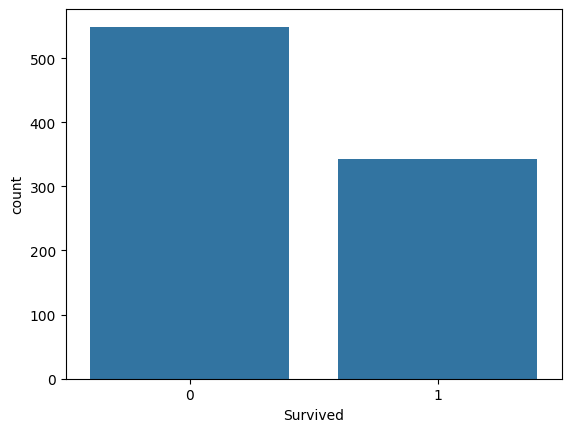

In [15]:
sns.countplot(x='Survived', data=train_df)

Как и было написано - погибших +- в полтора раза больше, чем выживших, будем иметь в виду.
Взглянем на основные распределения Sex/Pclass значений, сравним примерное соотношение train/test.


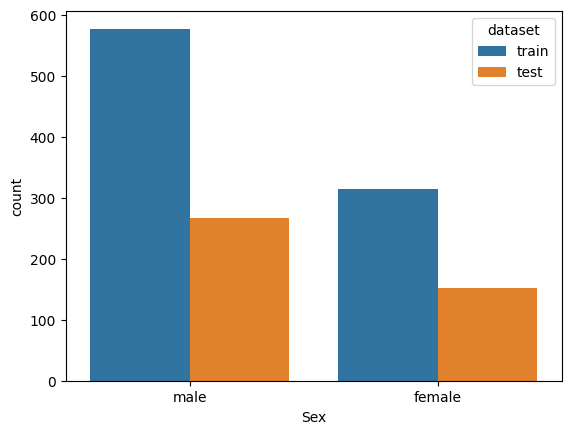

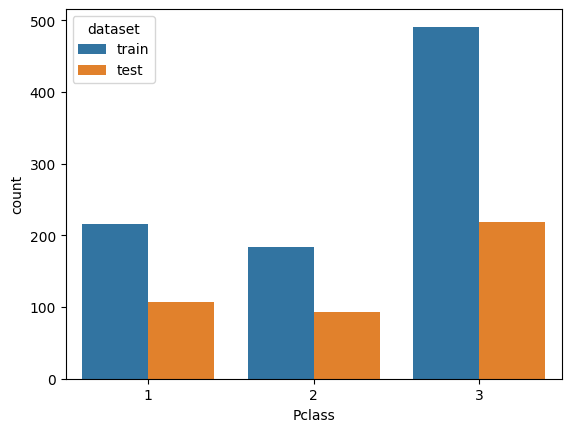

In [24]:
train_temp = train_df.copy()
train_temp['dataset'] = 'train'
test_temp = test_df.copy()
test_temp['dataset'] = 'test'
combined = pd.concat([train_temp, test_temp])

sns.countplot(x='Sex', hue='dataset', data=combined)
plt.show()

sns.countplot(x='Pclass', hue='dataset', data=combined)
plt.show()

Распределение основных признаков у train/test кажется равномерным, перекосов не видно, примерная природа признаков похожа
Взглянем на Age подробнее, интересно распределение

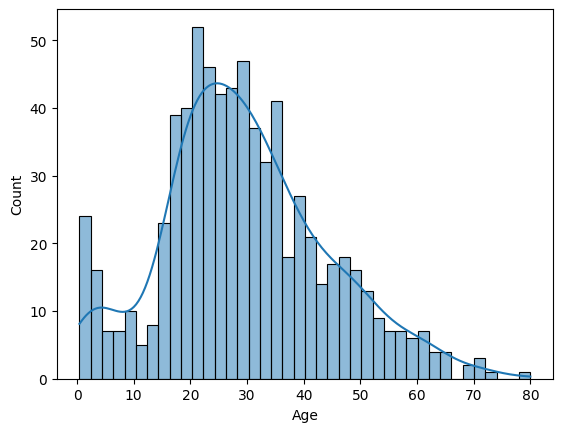

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [34]:
sns.histplot(train_df['Age'], kde=True, bins=40)
plt.show()

train_df['Age'].describe()

Медиана висит у 28-29 лет, там же и большее количество пассажиров, 80 лет из max - реальный возраст и единичный случай, не шум. Хвостик скошен вправо, также большая масса детей-подростков не исключение на борту, их реально не мало.
Взглянем на распределение выживших/погибших по возрастам


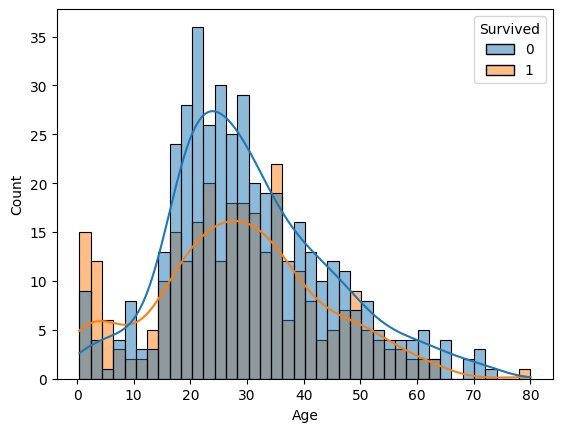

In [37]:
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, bins=40)
plt.show()

Сильное различие вначале графика - детей/подростков выжило критически больше, стоит иметь в виду.
Медианные же возраста (20-50 лет) в основном погибло намного больше, чем выжило. После 65 вовсе нет выживших, кроме 80-ти летнего счастливчика. Стоит посмотреть на то же распределение, но с точки зрения пола.

<Axes: xlabel='Sex', ylabel='count'>

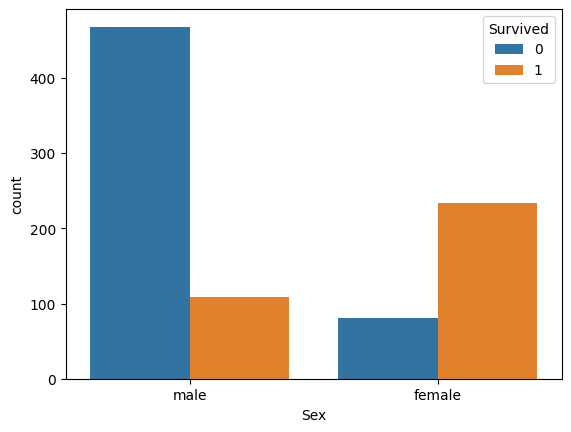

In [38]:
sns.countplot(data=train_df, x='Sex', hue='Survived')

Посмотрели и утвердили глазками главную мысль - женщин спасали больше, соотношение погибло/выжило у них критически отличается от мужчин.
Интересно посмотреть на распределение выживших и погибших женщин/и отдельно мужчин относительно возраста

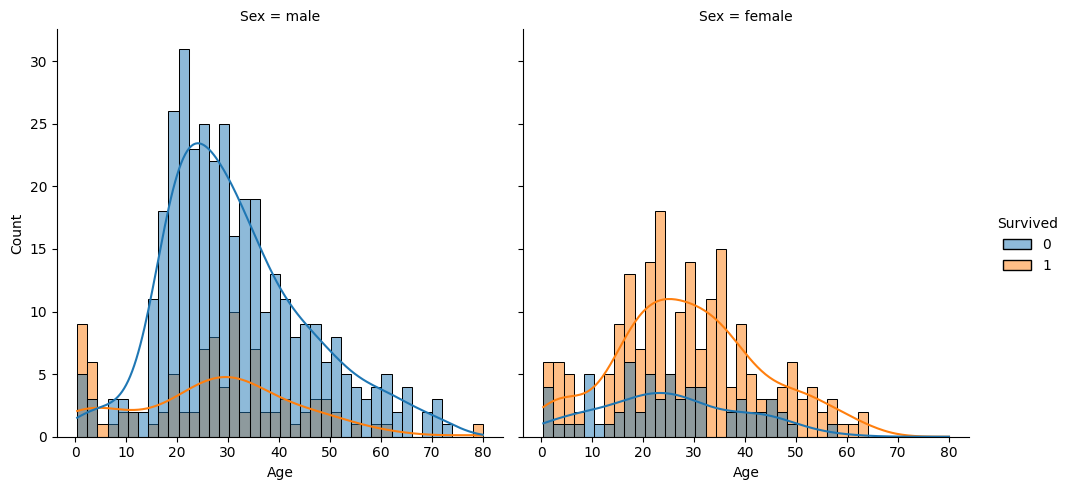

In [40]:
sns.displot(data=train_df, x='Age', hue='Survived', col='Sex', kde=True, bins=40)
plt.show()

Радует то, что хотя бы детей спасали без полового признака. В принципе график мужчин почти идентичен общему графику, но у женщин корректировки и различия немного есть (ибо их спасали больше): основная масса погибших у них 18-33 + 38-50 лет, в остальном бабушек и теть старше 50 спасали почти всех. 

Пока идей по Age/Survived/Sex нет, интересно глянуть на связки с Fare.

<Axes: xlabel='Fare', ylabel='Count'>

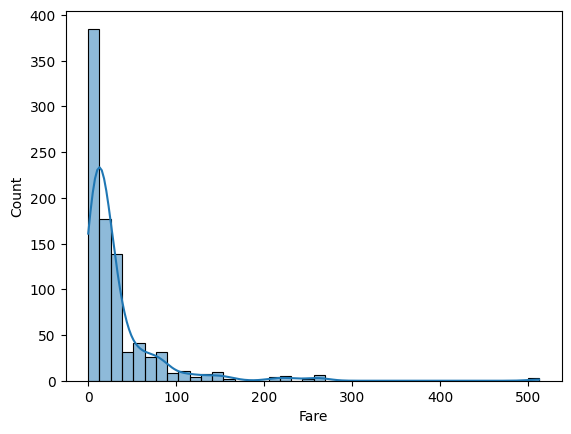

In [43]:
sns.histplot(data=train_df, x='Fare', bins=40, kde=True)

Основная масса билетов до 50 баксов, скорее всего это цена самого дешевого и общего класса билетов, проверим эту теорию в связке с Pclass. Билет за 500 баксов - аномальное явление, но реальное, букально единичный случай.

<Axes: xlabel='Fare', ylabel='Count'>

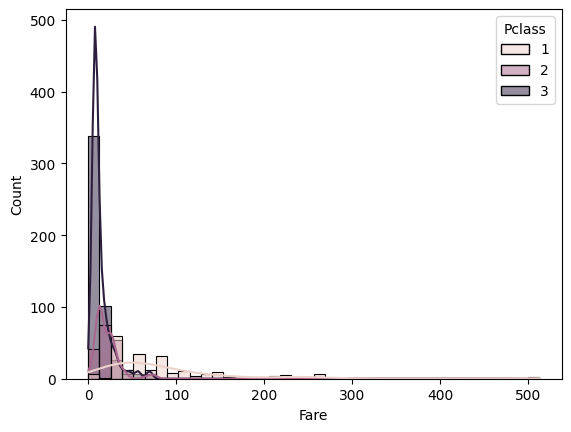

In [46]:
sns.histplot(data=train_df, x='Fare', hue='Pclass', kde=True, bins=40)

что и следовало ожидать: дешевый 3 класс - основная масса билетов, +- 15 баксов, средний второй класс больше про 20-30 баксов. Элита же расположилась на всем остальном продольном сегменте по ценникам, кто во что был горазд. Дальше интересно посмотреть на Fare относительно Survived.

<Axes: xlabel='Fare', ylabel='Count'>

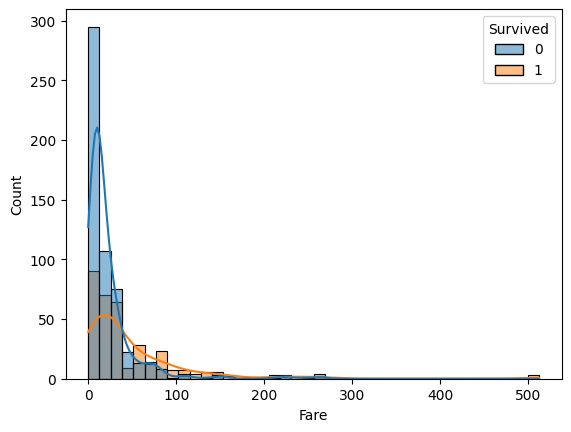

In [49]:
sns.histplot(data=train_df, x='Fare', hue='Survived', bins=40, kde=True)

Билеты дороже 50 баксов выделились: элита спасалась охотнее, дешевый класс из-за своей большой массы понятное дело пошел под общую картину соотношения Survived. Стоит взглянуть на Pclass и его отношения к выживаемости

<Axes: xlabel='Pclass', ylabel='count'>

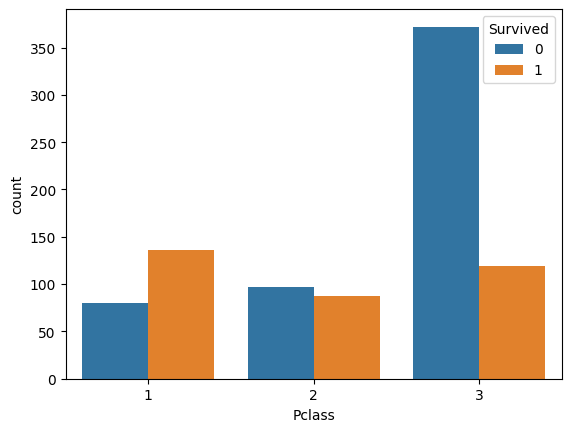

In [57]:
sns.countplot(data=train_df, x='Pclass', hue='Survived')

3 дешевый класс преимущественно погибал в отличие от 1 класса, у которого соотношение крайне меняется в сторону выживших, у среднего же класса соотношение почти одинаковое. Оффтопа ради глянем, какой пол оказался более меркантильным.

<Axes: xlabel='Pclass', ylabel='count'>

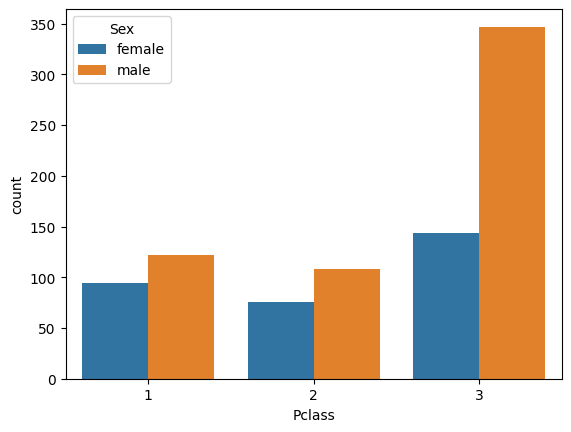

In [63]:
sns.countplot(data=train_df, x='Pclass', hue='Sex')

У 3 класса билетов мужчин оказалось более, чем в 2 раза больше женщин, но у среднего-дорогого классов соотношение близится к одинаковому, возможно, просто ехали "парочками", но сильно полезной информации нам эта статистика не дает, идем дальше.

Займемся SibSp, Parch и в частности Embarked.

<Axes: xlabel='SibSp', ylabel='count'>

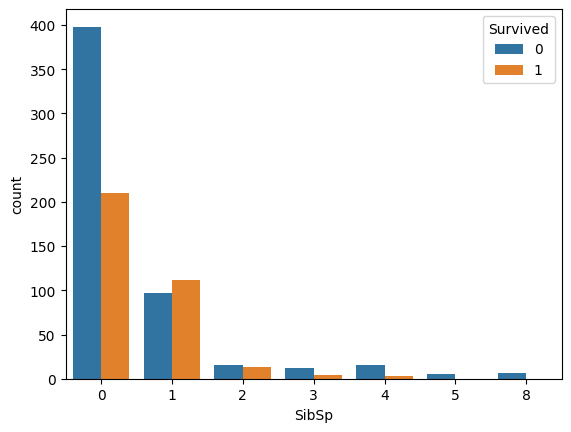

In [65]:
sns.countplot(data=train_df, x='SibSp', hue='Survived')

<Axes: xlabel='Parch', ylabel='count'>

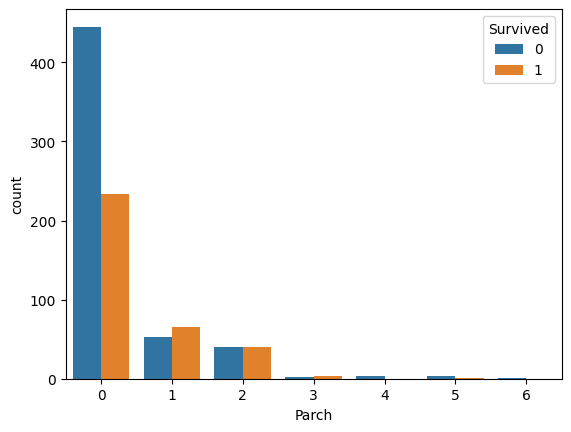

In [67]:
sns.countplot(data=train_df, x='Parch', hue='Survived')

"Нулевые" семьянины преимущественно погибали; Parch и SipSp со значением 1 преимущественно выживал, чем погибал, у значения "2" в основном равное соотношение, но в основном значения "3" и более погибали. Люди с большими семьями гибли больше, как и люди совсем без семей, золотая середина преимущественно выживала. Взглянем на Embarked

<Axes: xlabel='Embarked', ylabel='count'>

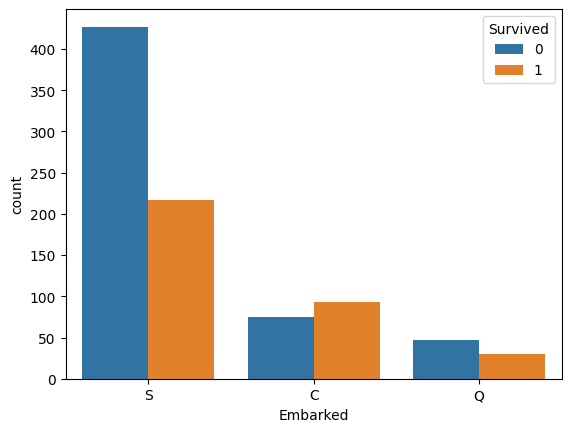

In [70]:
sns.countplot(data=train_df, x='Embarked', hue='Survived')

C значение в основном выживало, при этом Q и S в основном относительно с одинаковым соотношением погибало больше, чем выживало (но S побольше гибло в долевом отношении). Перейдем к построению матрице корреляций

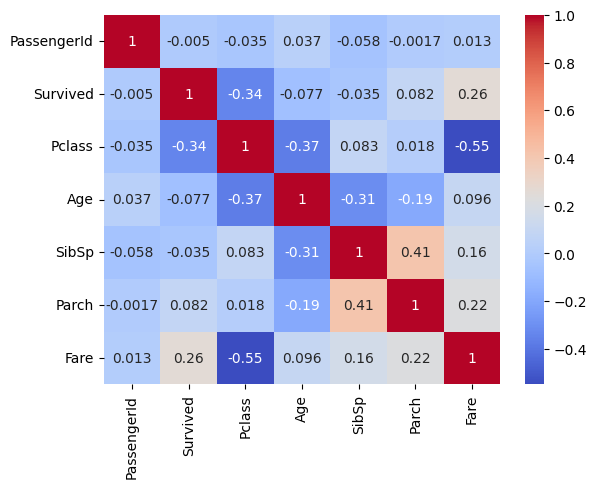

In [71]:
correlation_matrix = train_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

1) Parch и SibSp неплохо зависимы (0.41);
2) с самим таргетом Survived наибольшую зависимость имеет Fare (0.26), при этом модуль связи Survived и Pclass имеет смысл заметить, при 1 классе значение сильно отрицательное и перевешивает в эту сторону, то самое наше "дешевый класс живет меньше"
3) (имеет смысл рассмотреть возможность совместить Parch и SibSp)



### Основные промежуточные наблюдения
- Таргет: ~62% погибло, ~38% выжило
- Sex — сильнейший одиночный признак
- Pclass — по модулю корреляции (−0.34) это на самом деле самая сильная связь с таргетом во всей матрице
- Age — распределение скошено вправо, медиана ~28; дети выживали заметно чаще; экстремумы (80 лет) — реальные
- Fare — тоже скошено вправо; сильно завязан на Pclass (-0.55); часть его связи с Survived, вероятно, унаследована от Pclass, а не самостоятельна.
- Fare+Sex — кажущийся паттерн ("женщины тратили больше") объяснился составом классов по полу
- SibSp/Parch — "золотая середина" (1-2 спутника) выживает лучше, чем полное одиночество или большая группа; сами коррелируют друг с другом (0.41) — кандидаты на объединение в один признак.
- Embarked — порт C выделяется относительно более высокой долей выживших.
- Пропуски: Age ~20% (заполнимо), Embarked ~0.2% (несущественно), Cabin ~77% (требует решения)
- Name/Ticket/PassengerId — сырое содержимое бесполезно; из Name стоит достать титул; Ticket/PassengerId — кандидаты на полное исключение из признаков (последний нужен только для финального сабмита).

Создадим факт объема семьи/наличие одиночества

In [83]:
train_df['Family'] = train_df['Parch'] + train_df['SibSp'] + 1
train_df['IsAlone'] = (train_df['Family'] == 1).astype(int)

<Axes: xlabel='Family', ylabel='count'>

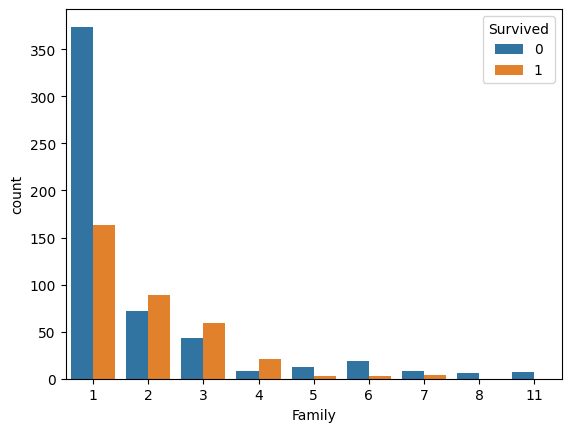

In [87]:
sns.countplot(data=train_df, x='Family', hue='Survived')

<Axes: xlabel='IsAlone', ylabel='count'>

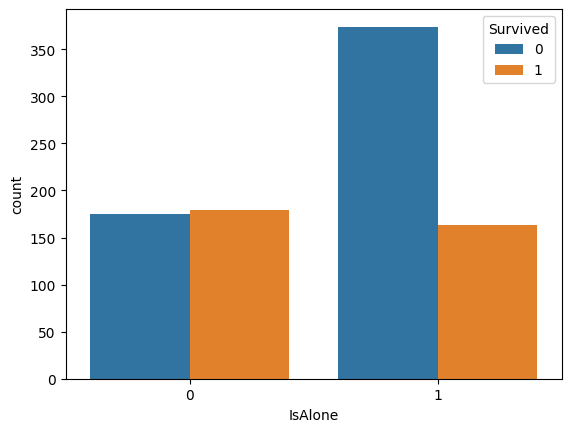

In [88]:
sns.countplot(data=train_df, x='IsAlone', hue='Survived')

Наглядно увидели, что одинокие пассажиры гибнут более в 2 раза чаще, чем живут. В том числе общая картина напоминает "горку": одинокие - много погибших, 2-4 человека в составе семьи - большая доля выживаемости (в 4 больше всего), от 5 и больше человек - низкая выживаемость. 
- Перейдем к обработке Name (вытащим титулы), проверим качество такого признака и есть ли в нем смысл

In [94]:
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=True)
(train_df['Title']).value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [102]:
train_df['Title'] = train_df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
train_df.loc[~(train_df['Title'].isin(common_titles)), 'Title'] = 'Rare'
train_df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

<Axes: xlabel='Title', ylabel='count'>

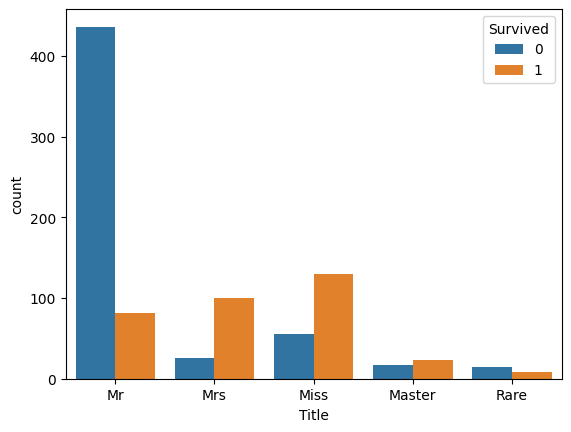

In [103]:
sns.countplot(data=train_df, x='Title', hue='Survived')

Хорошее наблюдение: значительная масса Mrs выжила, как и Miss, Mr наоборот по доле погибших в разы превышает выживших; Master тоже выделяется как более живучий, Rare - наоборот как более смертный. Теперь используем инструмент титулов для более корректного заполнения Age

<Axes: xlabel='Age', ylabel='Count'>

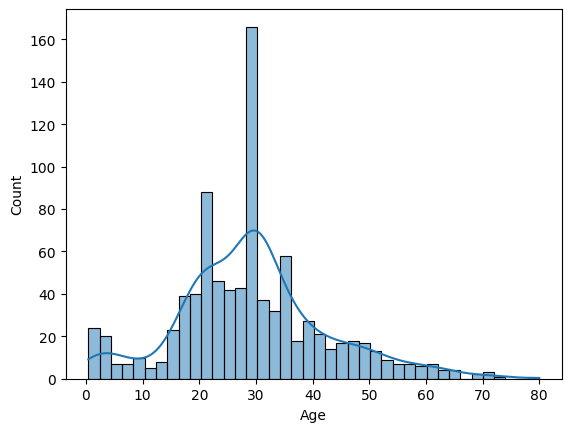

In [112]:
age_median = train_df.groupby('Title')['Age'].transform('median')
train_df['Age'] = train_df['Age'].fillna(age_median)
sns.histplot(data=train_df, x='Age', bins=40, kde=True)

После заполнения Nan значений медианными, появились нвоые пиковые значения - и по сути это нормально, десятки пропусков забились одинаковыми числами, зато такое заполнение основываясь на титулах более корректное. 

- Перейдем к обработке Cabin 
Сначала просмотрим в чем природа Nan значений, они случайные, или они держат за собой какой-то смысл 

<Axes: xlabel='Pclass', ylabel='count'>

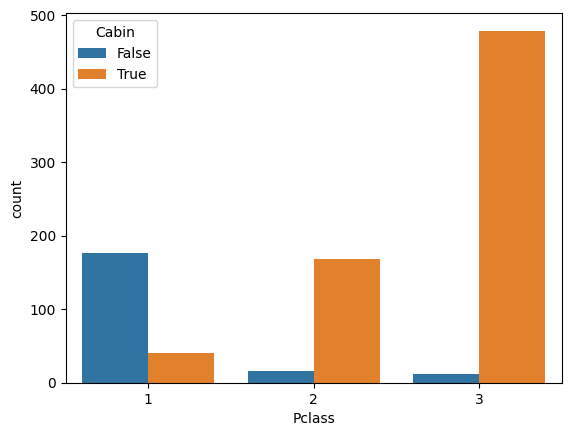

In [113]:
sns.countplot(data=train_df, x='Pclass', hue=train_df['Cabin'].isna())

Nan значения имеют не случайное положение, они крепко привязаны к 3 и в частности ко 2 классам билетов. Можно выявить из Cabin новый бинарный признак - имеется/не имеется ли номер каюты.


In [120]:
#train_df['HasCabin'] = train_df['Cabin'].notna().astype(int)
#train_df = train_df.drop(columns=['Cabin'])
train_df['HasCabin']

0      1
1      1
2      1
3      1
4      1
      ..
886    1
887    1
888    1
889    1
890    1
Name: HasCabin, Length: 891, dtype: int64

HasCabin отобразит имеется ли инфа о номере каюты или нет. Перейдем к заполнению маленьких пропусков в Embarked (заполним самым частым классом)

In [121]:
embarked_mode = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(embarked_mode)